In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import os
import copy
import json


from model.loss_function.siamese.custom_siamese_loss import CustomSiameseLoss
from model.architecture.basic_siamese_model import BasicSiameseModel
from model.architecture.advanced_siamese_model import AdvancedSiameseModel
from data_augmentation.matrices_loader import MatricesLoader
from data_augmentation.datasets.siamese_AHP_matrix_dataset import SiameseAHPMatrixDataset
from data_augmentation.generator.target_cr_generator import TargetCRMatricesGenerator
from utils.phase import Phase
from visualization.results.metrics_visualizator import MetricsVisualizator

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device used: cpu


/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
IS_UNIFORM = True
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4]
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

In [4]:
def load_train_dataset(loader: MatricesLoader):
    all_matrices = []
    all_comparison_matrices = []
    all_weights = []

    for cr in CONSISTENCY_RATES:
        matrices, weights = loader.load_noisy_cr_matrices(Phase.TRAIN, cr, IS_UNIFORM, CRITERIA_NUM, TRAIN_MATRICES_NUM)
        generator = TargetCRMatricesGenerator(matrices.shape[0], matrices.shape[1], cr)
        comparison_matrices = generator.from_weights(weights)

        all_matrices.append(matrices)
        all_comparison_matrices.append(comparison_matrices)
        all_weights.append(weights)
    
    final_matrices = np.concatenate(all_matrices, axis=0)
    final_weights = np.concatenate(all_weights, axis=0)
    final_comparison_matrices = np.concatenate(all_comparison_matrices, axis=0)
    dataset = SiameseAHPMatrixDataset(final_matrices, final_comparison_matrices, final_weights)

    print(f"Train dataset was successfully created and {len(dataset)} matrices was uploaded")
    return dataset


def load_valid_dataset(loader: MatricesLoader):
    all_matrices = []
    all_comparison_matrices = []
    all_weights = []

    for cr in CONSISTENCY_RATES:
        matrices, weights = loader.load_noisy_cr_matrices(Phase.VALIDATION, cr, IS_UNIFORM, CRITERIA_NUM, VALID_MATRICES_NUM)
        generator = TargetCRMatricesGenerator(matrices.shape[0], matrices.shape[1], cr)
        comparison_matrices = generator.from_weights(weights)

        all_matrices.append(matrices)
        all_comparison_matrices.append(comparison_matrices)
        all_weights.append(weights)
    
    final_matrices = np.concatenate(all_matrices, axis=0)
    final_weights = np.concatenate(all_weights, axis=0)
    final_comparison_matrices = np.concatenate(all_comparison_matrices, axis=0)
    dataset = SiameseAHPMatrixDataset(final_matrices, final_comparison_matrices, final_weights)

    print(f"Validation dataset was successfully created and {len(dataset)} matrices was uploaded")
    return dataset


def save_model_weights_histories(model: torch.nn.Module, history: dict[str, list], model_type_name: str, name: str):
    base_dir = "models"
    dir_path = os.path.join(base_dir, model_type_name)

    if not os.path.exists(dir_path):
        os.makedirs(dir_path)

    model_path = os.path.join(dir_path, f"model_{name}.pth")
    history_path = os.path.join(dir_path, f"history_{name}.json")

    torch.save(model.state_dict(), model_path)
    with open(history_path, "w", encoding="utf-8") as file:
        json.dump(history, file, indent=4)
        
    print(f"History and model: {name} was saved in {dir_path}")


In [5]:
loader = MatricesLoader()
train_dataset = load_train_dataset(loader)
valid_dataset = load_valid_dataset(loader)

KeyboardInterrupt: 

In [ ]:
def train_model(model, train_dataset, valid_dataset, device, epochs=100, batch_size=32, 
                lr=0.001, early_stopping = True, patience = 15):
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)

    criterion = CustomSiameseLoss(lambda_cop=1.0, lambda_rec=0.5, lambda_stab=0.2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train': [], 'valid': []}
    best_valid_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        
        model.train()
        train_epoch_loss = 0.0
        
        for batch_idx, (m1_batch, m2_batch, weights_batch) in enumerate(train_dataloader):
            m1_batch = m1_batch.to(device)
            m2_batch = m2_batch.to(device)
            weights_batch = weights_batch.to(device)

            logits1, logits2 = model(m1_batch, m2_batch)
            loss = criterion(logits1, logits2, weights_batch, m1_batch.squeeze(1), m2_batch.squeeze(1))

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_epoch_loss += loss.item()

        avg_train_loss = train_epoch_loss / len(train_dataloader)
        history['train'].append(avg_train_loss)

        model.eval()
        valid_epoch_loss = 0.0
        
        with torch.no_grad():
            for m1_batch, m2_batch, weights_batch in valid_dataloader:
                m1_batch = m1_batch.to(device)
                m2_batch = m2_batch.to(device)
                weights_batch = weights_batch.to(device)

                logits1, logits2 = model(m1_batch, m2_batch)
                
                val_loss = criterion(logits1, logits2, weights_batch, m1_batch.squeeze(1), m2_batch.squeeze(1))
                valid_epoch_loss += val_loss.item()
                
        avg_valid_loss = valid_epoch_loss / len(valid_dataloader)
        history['valid'].append(avg_valid_loss)

        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch number [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.6f} | Valid Loss: {avg_valid_loss:.6f}")

        if early_stopping and epochs_no_improve >= patience:
            print(f"\nEARLY STOPPING in epoch {epoch + 1}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Wages are restored to the best valid loss: {best_valid_loss:.6f}")

    return model, history

In [ ]:
model = BasicSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, loss_history = train_model(model, train_dataset, valid_dataset, device, epochs=500)

save_model_weights_histories(model, loss_history, "siamese", "basic_1000m")

Epoch number [10/500] | Train Loss: 0.019177 | Valid Loss: 0.018254
Epoch number [20/500] | Train Loss: 0.018604 | Valid Loss: 0.017659
Epoch number [30/500] | Train Loss: 0.018240 | Valid Loss: 0.017239
Epoch number [40/500] | Train Loss: 0.018059 | Valid Loss: 0.017034
Epoch number [50/500] | Train Loss: 0.018034 | Valid Loss: 0.017000
Epoch number [60/500] | Train Loss: 0.017952 | Valid Loss: 0.017087
Epoch number [70/500] | Train Loss: 0.017924 | Valid Loss: 0.016947
Epoch number [80/500] | Train Loss: 0.017854 | Valid Loss: 0.016783
Epoch number [90/500] | Train Loss: 0.017814 | Valid Loss: 0.017187
Epoch number [100/500] | Train Loss: 0.017786 | Valid Loss: 0.016925
Epoch number [110/500] | Train Loss: 0.017734 | Valid Loss: 0.016667
Epoch number [120/500] | Train Loss: 0.017768 | Valid Loss: 0.016716

EARLY STOPPING in epoch 126.
Wages are restored to the best valid loss: 0.016573
History and model: basic_1000m was saved in models/siamese


In [ ]:
model = AdvancedSiameseModel(n_criteria=CRITERIA_NUM)
trained_model, loss_history = train_model(model, train_dataset, valid_dataset, device, epochs=500)

save_model_weights_histories(model, loss_history, "siamese", "advanced_10000m")

Epoch number [10/500] | Train Loss: 0.017460 | Valid Loss: 0.016564
Epoch number [20/500] | Train Loss: 0.015866 | Valid Loss: 0.015371
Epoch number [30/500] | Train Loss: 0.015108 | Valid Loss: 0.014885
Epoch number [40/500] | Train Loss: 0.014651 | Valid Loss: 0.014850
Epoch number [50/500] | Train Loss: 0.014247 | Valid Loss: 0.014562
Epoch number [60/500] | Train Loss: 0.013975 | Valid Loss: 0.014674
Epoch number [70/500] | Train Loss: 0.013719 | Valid Loss: 0.014798

EARLY STOPPING in epoch 70.
Wages are restored to the best valid loss: 0.014512
History and model: advanced_1000m was saved in models/siamese


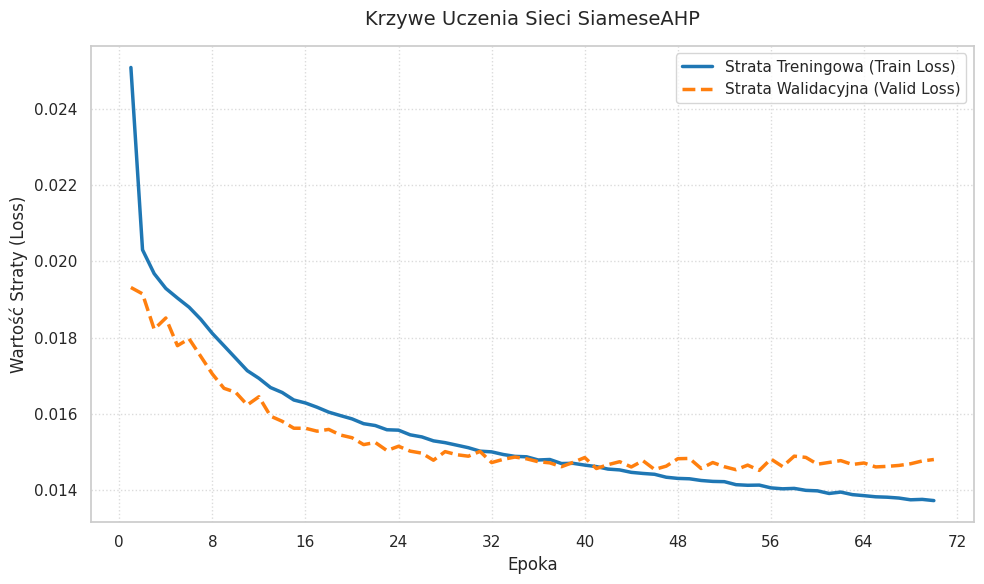

In [ ]:
visualizator = MetricsVisualizator()
visualizator.display_loss(loss_history)